In [36]:
import kagglehub
import cv2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
import tensorflow as tf
import cv2

In [5]:
path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')
# print(path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.


In [6]:
# data_path = '/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray'

In [7]:
# os.listdir(data_path+'/train/PNEUMONIA')

In [8]:
# cv2.imread(
#     os.path.join(data_path + '/train/PNEUMONIA',
#                  os.listdir(data_path + '/train/PNEUMONIA')[0]),
#           cv2.IMREAD_GRAYSCALE)

In [9]:
# def image_read(sub_folder: str)->list:
#   full_path = os.path.join(data_path, sub_folder)
#   x = [
#       cv2.imread(os.path.join(full_path, fn)) for fn in os.listdir(full_path)
#   ]
#   return x

In [10]:
# # train/pneumonia
# # train/normal
# # test/pneumonia
# # test/normal

# x_train = image_read('train/PNEUMONIA')
# y_train = [1] * len(x_train)
# x_train += image_read('train/NORMAL')
# y_train += [0] * (len(x_train) - len(y_train))

# x_test = image_read('test/PNEUMONIA')
# y_test = [1] * len(x_test)
# x_test += image_read('test/NORMAL')
# y_test += [0] * (len(x_test) - len(y_test))


In [11]:
LABELS_LIST = ['NORMAL', 'PNEUMONIA']
IMAGE_SIZE = 150

In [12]:
# os.listdir('.')

In [13]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(path, 'chest_xray/chest_xray/train'),
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(path, 'chest_xray/chest_xray/val'),
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(path, 'chest_xray/chest_xray/test'),
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=32,
    shuffle=False
)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


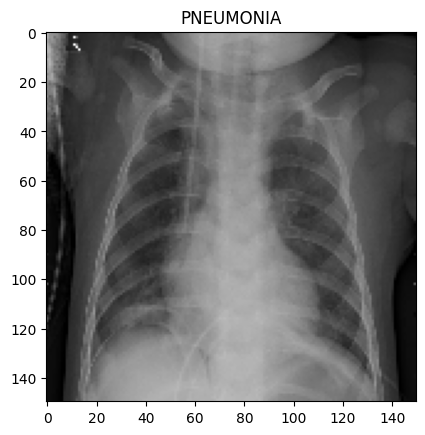

In [14]:
for images, labels in train_ds.take(1):
  plt.imshow(images[0].numpy().astype('uint16'))
  plt.title(LABELS_LIST[labels[0].numpy().astype(int)])

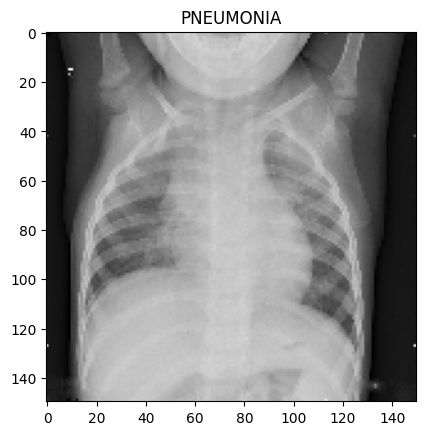

In [15]:
for images, labes in val_ds.take(1):
  plt.imshow(images[0].numpy().astype('uint32'))
  plt.title(LABELS_LIST[labels[0].numpy().astype(int)])


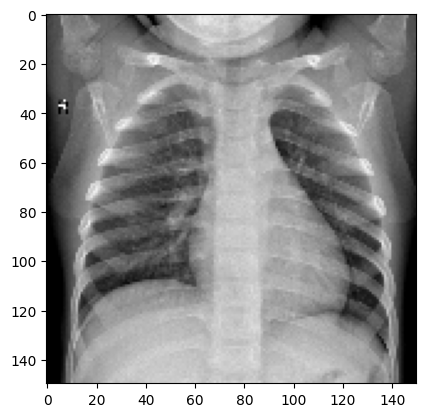

In [16]:
#set of tuples containing tensor objects, [0] is images(32 images i.e. batch size) , [1] is lables
plt.imshow([*train_ds.take(1)][0][0][0].numpy().astype('uint8'))
# [*train_ds.take(5)][3][1].numpy().shape

In [17]:
?tf.keras.layers.Conv2D

In [18]:
# tf.keras.layers.Conv2D(filters:int, kernal_size:tuple/int,
# strides:int/tuple, padding: valid (i.e.no-padding) or same
#activation='relu', input_shape=tuple,

In [19]:
# ?tf.keras.layers.MaxPooling2D #while frame moving, the maximum from the frame will be selected, avgpooling also available.

In [34]:
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Conv2D(filters=32,
    kernel_size=(3,3),
    strides=1,
    padding='valid',
    activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D(2,2))

model.add(tf.keras.layers.Conv2D(
    filters=64,
    kernel_size=(3,3),
    strides=1,
    padding='valid', # or 'sample'
    activation='relu'
    ))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D(2,2))


model.add(tf.keras.layers.Conv2D(
  filters=128,
  kernel_size=(3,3),
  strides=1,
  padding='valid',
  activation='relu',
))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D(2,2)) #down sampling

model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(units=512,
                                activation=tf.keras.activations.leaky_relu,
                                # regularizer=tf.keras.regularizers.l2
                                ))
model.add(tf.keras.layers.Dropout(0.25))
model.add(tf.keras.layers.Dense(units=1,
                                activation=tf.keras.activations.sigmoid))


In [21]:
# ?tf.keras.optimizers.Adam

In [33]:
#compile model - (basic ex: With Stochastic Gradient Descent optimizer using MSE as loss)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), #RMSProp() #SGD
    loss=tf.keras.losses.binary_crossentropy,
    metrics=['accuracy']
)

In [23]:
# ?model.fit
#epoch=15 ;
#batch_size=32 samples, so 5216/32 = 163 batches.

In [24]:
history = model.fit(
    train_ds, # A backend-native tensor
    validation_data=test_ds,
    epochs=10
    )

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 508s 3s/step - accuracy: 0.8378 - loss: 24.8412 - val_accuracy: 0.7548 - val_loss: 35.3855
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 493s 3s/step - accuracy: 0.9359 - loss: 4.4752 - val_accuracy: 0.5256 - val_loss: 45.8859
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 485s 3s/step - accuracy: 0.9507 - loss: 1.7802 - val_accuracy: 0.6715 - val_loss: 25.2878
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 496s 3s/step - accuracy: 0.9643 - loss: 0.5365 - val_accuracy: 0.7003 - val_loss: 13.9950
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 498s 3s/step - accuracy: 0.9726 - loss: 0.2576 - val_accuracy: 0.8237 - val_loss: 3.8570
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 494s 3s/step - accuracy: 0.9678 - loss: 0.3167 - val_accuracy: 0.7500 - val_loss: 7.9573
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 509s 3s/step - accuracy: 0.9745 - loss: 0.1685 - val_accuracy: 0.7660 - val_loss: 3.6703
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 503s 3s/step - accuracy: 0.9847 - loss: 0.0638 - val

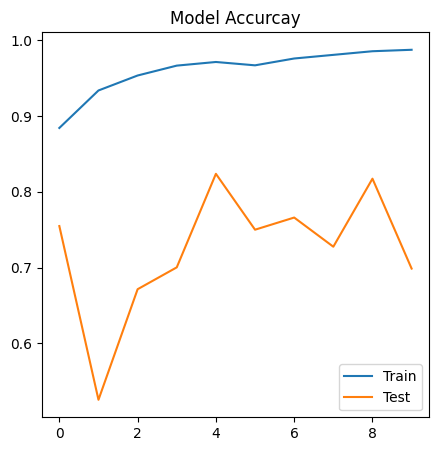

In [32]:
plt.figure(figsize=(5,5))
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.legend(['Train', 'Test'])
plt.title('Model Accurcay')
plt.show()